<a href="https://colab.research.google.com/github/Masud690/Swiggy-Sales-Analysis/blob/main/swiggy_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
data = pd.read_excel('/content/swiggy_data.xlsx')

In [5]:
data.head(3)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48


**Metadata**

In [14]:
print("No of Rows:",data.shape[0], "Columns:",data.shape[1])

No of Rows: 197430 Columns: 10


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


In [15]:
data.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


**KPI**'s

In [22]:
#Total Sales

print("total_Sales_value",round(data['Price (INR)'].sum(),2))

total_Sales_value 53012505.77


In [23]:
#Avg Rating

print("Avg_Rating",round(data['Rating'].mean(),2))

Avg_Rating 4.34


In [24]:
#Avg order Value

print("Avg_Order_Value",round(data['Price (INR)'].mean(),2))

Avg_Order_Value 268.51


In [25]:
#Rating Count

print("Rating_count",round(data['Rating Count'].sum(),2))

Rating_count 5591574


In [30]:
#Total Orders

print("Total_Orders",data['Order Date'].count())

Total_Orders 197430


**Charts Design**

`Monthly Sales Trends`

<Axes: title={'center': 'Monthly Sales Trends'}, xlabel='YearMonth', ylabel='Price (INR)'>

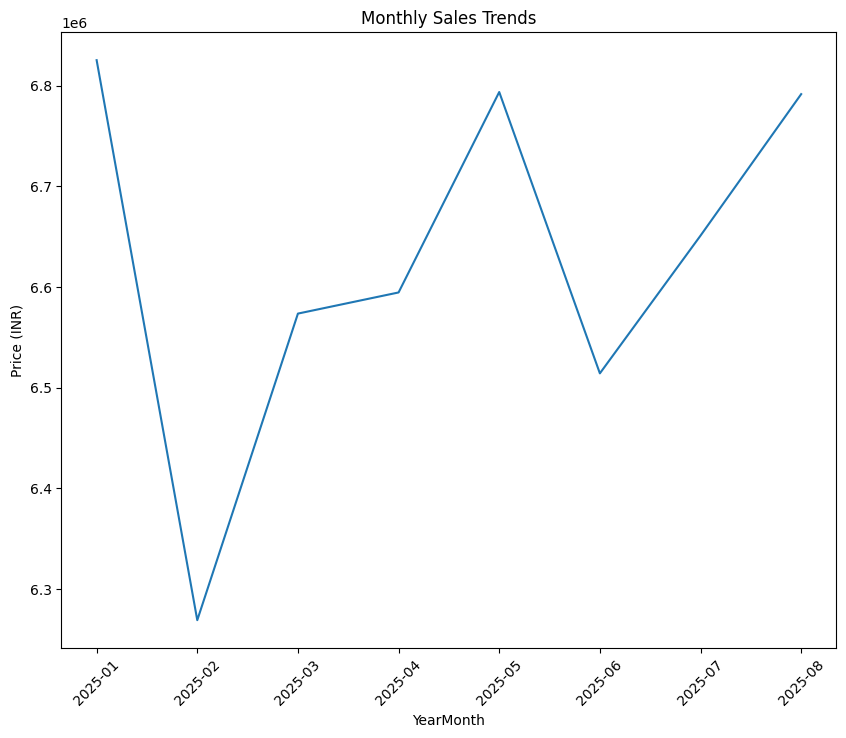

In [43]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['YearMonth'] = data['Order Date'].dt.to_period("M").astype(str)

Monthly_revenue =  data.groupby("YearMonth")['Price (INR)'].sum().reset_index()

plt.figure(figsize=(10,8))
plt.xlabel("YearMonth")
plt.ylabel("Price (INR)")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trends")
sns.lineplot(x='YearMonth',y='Price (INR)',data=Monthly_revenue)


`Daily Sales Trends`



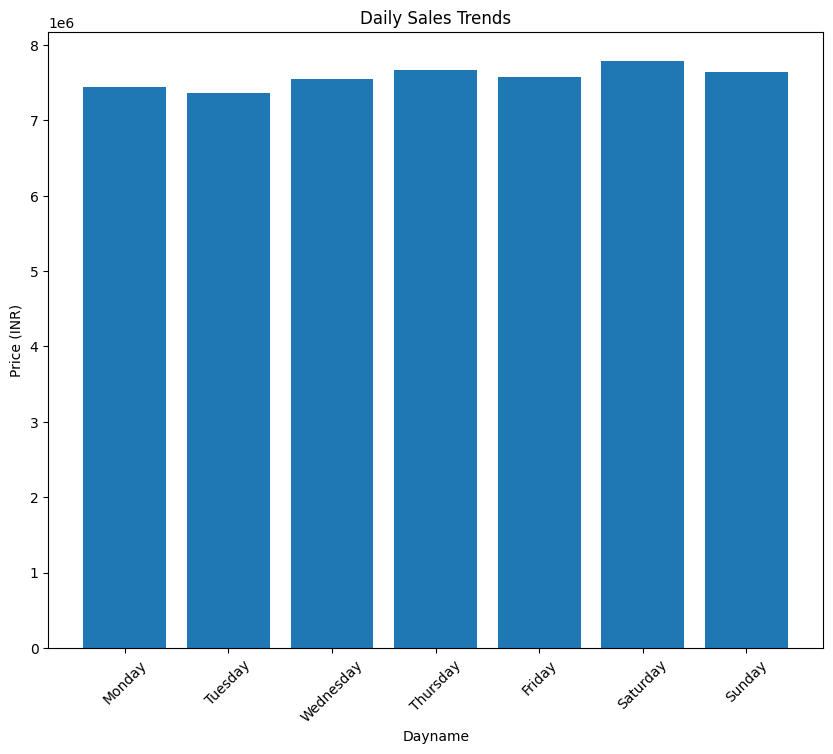

In [48]:
data['Dayname']= pd.to_datetime(data['Order Date']).dt.day_name()
daily_revenue = data.groupby('Dayname')['Price (INR)'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])


plt.figure(figsize=(10,8))
plt.xlabel("Dayname")
plt.ylabel("Price (INR)")
plt.xticks(rotation=45)
plt.title("Daily Sales Trends")
plt.bar(daily_revenue.index,daily_revenue.values)

plt.show()

`Total Sales by Food`

In [52]:
non_veg_keywords = ['chicken','egg','fish','motton','prawn',
                    'biriyani','kabab','kebab','non-veg','non veg']

data['Food Category']= np.where(
    data['Dish Name'].str.lower().str.contains('|'.join(non_veg_keywords),na = False),'non-veg','veg'
)

In [53]:
Food_revenue = (data.groupby('Food Category')['Price (INR)'].sum().reset_index())


In [55]:
fig = px.pie(Food_revenue,values='Price (INR)',names='Food Category',hole=0.5,
             title='Revenue Contribution: Veg vs Non-Veg')

fig.show()

`Total Sales by State`

In [60]:
fig = px.bar(data.groupby('State',as_index=False)['Price (INR)'].sum().sort_values('Price (INR)',ascending=False),
             x = 'Price (INR)',y='State',
             title='Total Sales by State')
fig.update_layout(xaxis_title="Price (INR)",yaxis_title="State",height=600,yaxis = dict(autorange='reversed'))
fig.show()

`Quaterly Performance Summary`

In [62]:
data["Order_Date"] = pd.to_datetime(data["Order Date"])

data["Quarter"] = data["Order Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    data.groupby("Quarter", as_index=False)
    .agg(
        Total_Sales=("Price (INR)", "sum"),
        Avg_Rating=("Rating", "mean"),
        Total_Orders=("Order Date", "count")
    )
    .sort_values("Quarter")
)
quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667821.77,4.342643,73096
1,2025Q2,19902256.59,4.340011,74163
2,2025Q3,13442427.41,4.342359,50171


`Top 5 cities`

In [68]:
Top_5_cities = data.groupby('City')['Price (INR)'].sum().nlargest(5).sort_values(ascending=True).reset_index()

fig = px.bar(Top_5_cities, x='Price (INR)', y='City',
             title='Top 5 cities', color_discrete_sequence=['red'])

fig.show()

`*Weekly Sales Trends*`

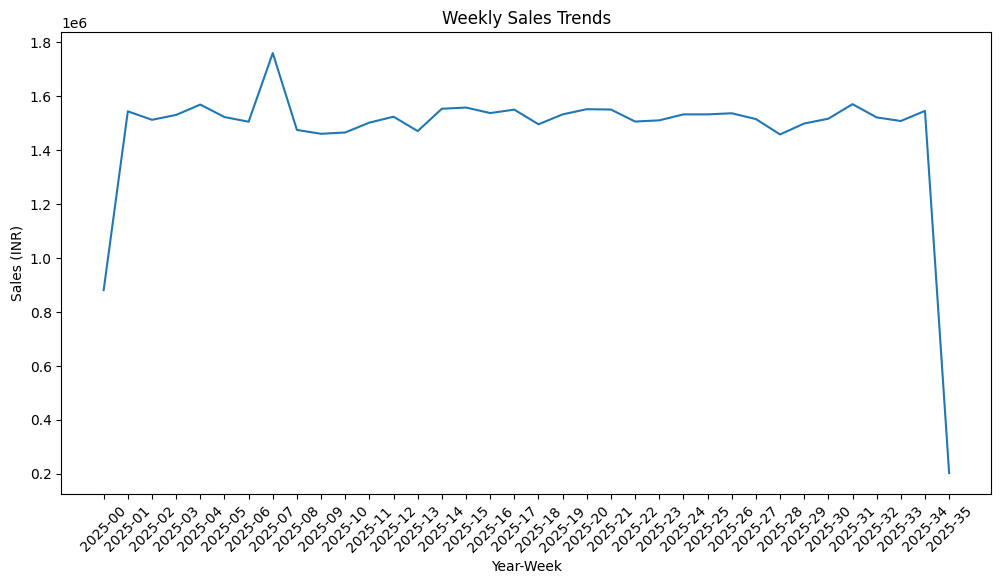

Peak Week:
 YearWeek          2025-07
Price (INR)    1760216.95
Name: 7, dtype: object

Lowest Week:
 YearWeek         2025-35
Price (INR)    201874.61
Name: 35, dtype: object

Sales Fluctuation (Std Dev): 247983.93634075174


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])

# Step 2: Create Year-Week column
data['YearWeek'] = data['Order Date'].dt.strftime('%Y-%U')

# Step 3: Weekly sales
weekly_sales = data.groupby('YearWeek')['Price (INR)'].sum().reset_index()

# Step 4: Plot weekly trend
plt.figure(figsize=(12,6))
sns.lineplot(x='YearWeek', y='Price (INR)', data=weekly_sales)

plt.xticks(rotation=45)
plt.xlabel("Year-Week")
plt.ylabel("Sales (INR)")
plt.title("Weekly Sales Trends")

plt.show()

# Step 5: Identify peak week (highest sales)
peak_week = weekly_sales.loc[weekly_sales['Price (INR)'].idxmax()]

# Step 6: Identify lowest week (drop)
low_week = weekly_sales.loc[weekly_sales['Price (INR)'].idxmin()]

print("Peak Week:\n", peak_week)
print("\nLowest Week:\n", low_week)

# Step 7: Measure consistency (standard deviation)
consistency = weekly_sales['Price (INR)'].std()
print("\nSales Fluctuation (Std Dev):", consistency)